# Netflix Content Analysis
**Exploratory Data Analysis | Python | Pandas | Matplotlib | Seaborn**

Dataset: Netflix Movies and TV Shows  
Goal: Understand content distribution, trends, and genre patterns on Netflix

---
## 1. Import Libraries

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Load & Explore Dataset

In [275]:
df = pd.read_csv('netflix1.csv')

print('Shape:', df.shape)
df.head(5)

Shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [277]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [279]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Check for null values per column
df.isnull().sum()

Duplicate rows: 0


show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [281]:
# Basic statistics for numerical columns
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


> **Observation:** Zero duplicates and no null values. `date_added` is stored as object — needs conversion to datetime.

---
## 3. Data Cleaning

In [287]:
# Convert date_added from object → datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year from date_added for trend analysis
df['year_added'] = df['date_added'].dt.year

# Extract numeric duration (removes 'min' or 'Seasons' text)
df['duration_clean'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   show_id         8790 non-null   object        
 1   type            8790 non-null   object        
 2   title           8790 non-null   object        
 3   director        8790 non-null   object        
 4   country         8790 non-null   object        
 5   date_added      8790 non-null   datetime64[ns]
 6   release_year    8790 non-null   int64         
 7   rating          8790 non-null   object        
 8   duration        8790 non-null   object        
 9   listed_in       8790 non-null   object        
 10  year_added      8790 non-null   int32         
 11  duration_clean  8790 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(8)
memory usage: 789.9+ KB


> **Data is clean and ready for analysis.**

---
## 4. Movies vs TV Shows

In [291]:
# Count each content type
type_counts = df['type'].value_counts()
type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

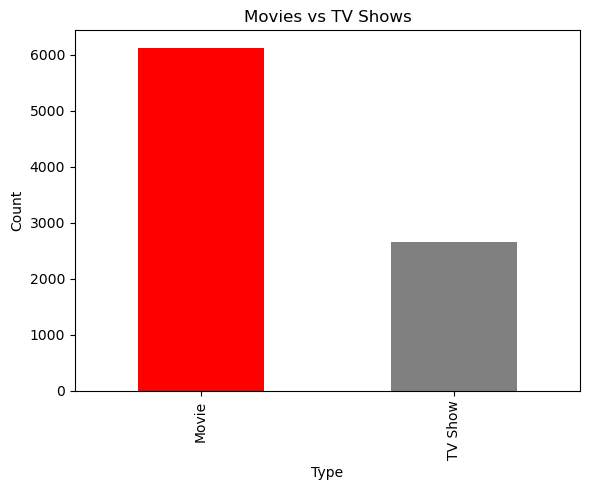

In [295]:
plt.figure(figsize=(6, 5))
type_counts.plot(kind='bar', color=['red', 'gray'])
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
## 5. Top 10 Countries by Content

In [298]:
# Get top 10 countries with the most titles
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

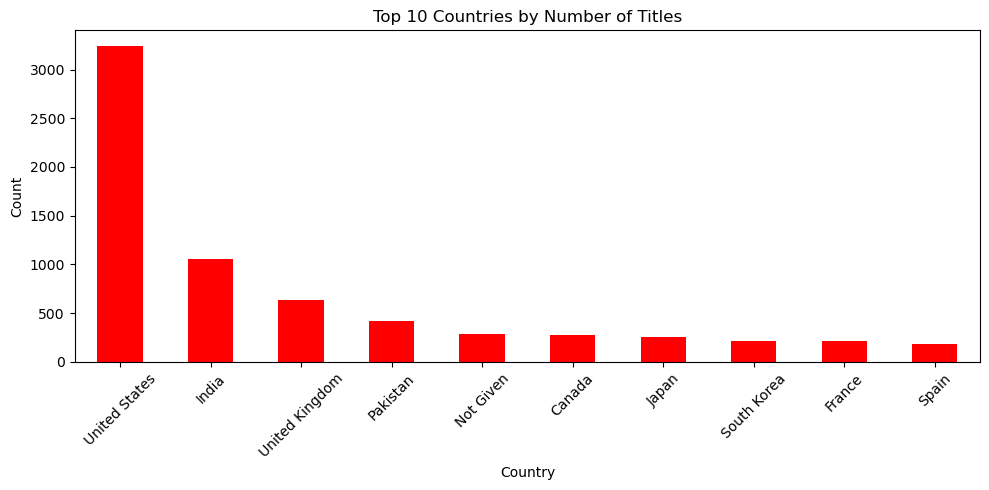

In [300]:
plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='red')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Content Added Per Year

In [303]:
# Count titles added each year, sorted descending
yearly = df['year_added'].value_counts().sort_index(ascending=False)
yearly

year_added
2021    1498
2020    1879
2019    2016
2018    1648
2017    1185
2016     426
2015      82
2014      24
2013      11
2012       3
2011      13
2010       1
2009       2
2008       2
Name: count, dtype: int64

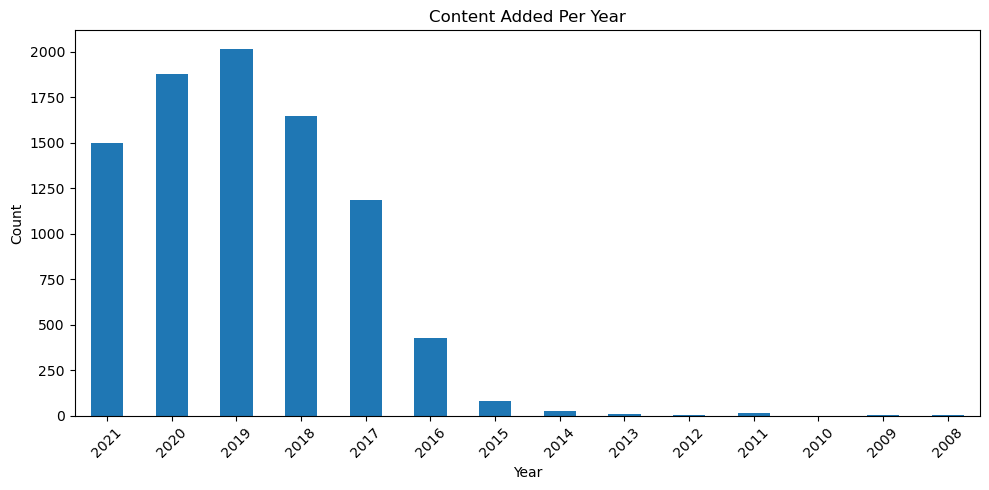

In [306]:
plt.figure(figsize=(10, 5))
yearly.plot(kind='bar')
plt.title('Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 7. Rating Distribution

In [309]:
# Count how many titles fall under each rating
ratings = df['rating'].value_counts()
ratings

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

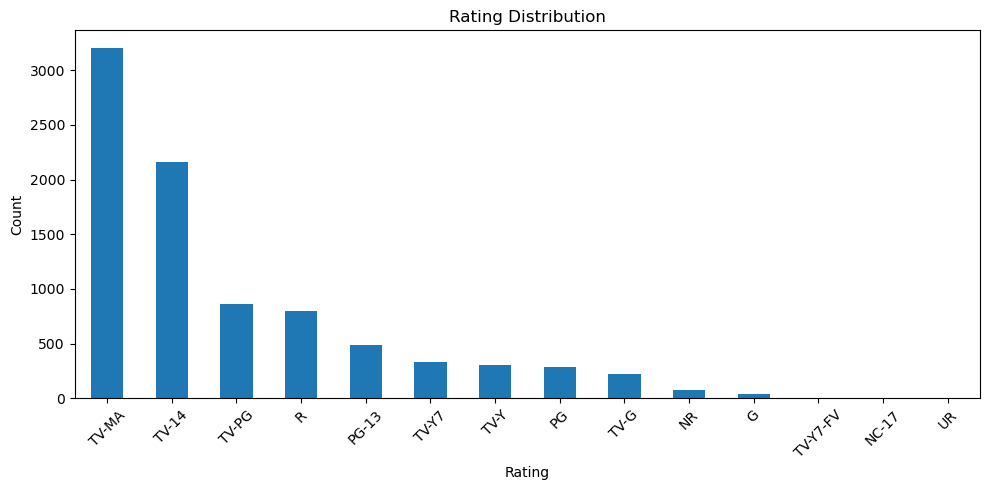

In [311]:
plt.figure(figsize=(10, 5))
ratings.plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 8. Movie Duration Distribution

In [314]:
# Filter only Movies for duration analysis
movies = df[df['type'] == 'Movie']
movies.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,duration_clean
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,90.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,125.0
6,s10,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",2021,104.0
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu...",2021,87.0


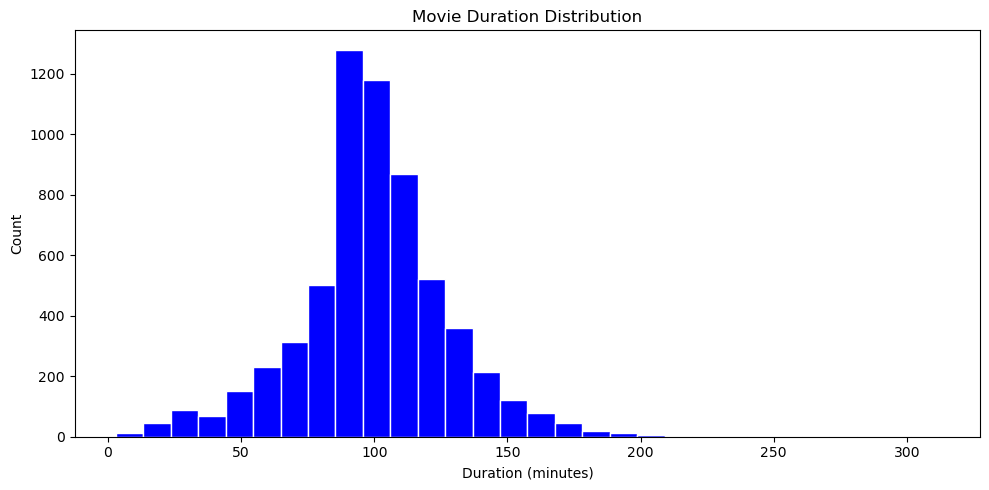

In [316]:
plt.figure(figsize=(10, 5))
plt.hist(movies['duration_clean'].dropna(), bins=30, color='blue', edgecolor='white')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
## 9. Top 10 Directors

In [319]:
# Top 10 directors — skipping index [0] because it contains 'Not Given'
top_directors = df['director'].value_counts().iloc[1:11]
top_directors

director
Rajiv Chilaka             20
Alastair Fothergill       18
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Jay Chapman               12
Martin Scorsese           12
Youssef Chahine           12
Name: count, dtype: int64

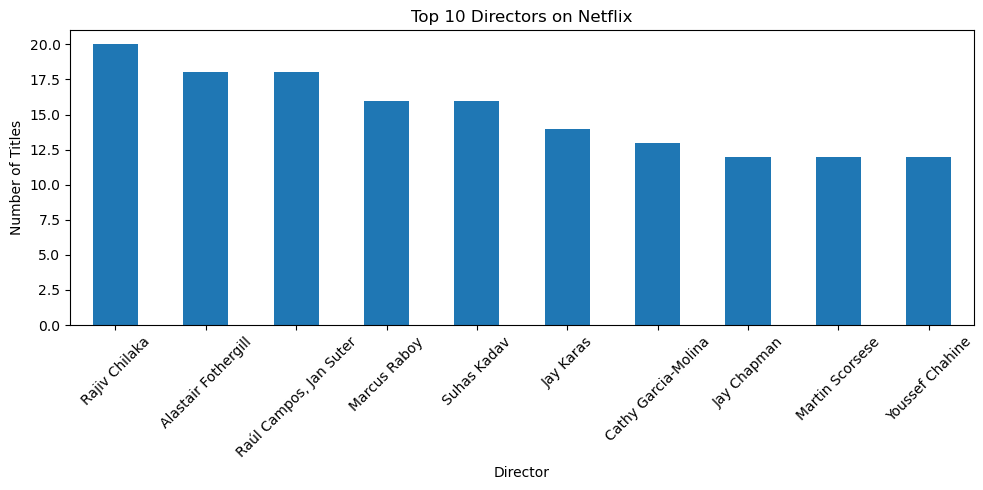

In [321]:
plt.figure(figsize=(10, 5))
top_directors.plot(kind='bar')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 10. Genre vs Content Type — Heatmap

In [324]:
# Step 1: Split comma-separated genres into a list per row
df['genre'] = df['listed_in'].str.split(',')

# Step 2: Explode so each genre gets its own row
df_genre = df.explode('genre')

# Step 3: Remove extra spaces around genre names
df_genre['genre'] = df_genre['genre'].str.strip()

df_genre['genre']

0                Documentaries
1               Crime TV Shows
1       International TV Shows
1        TV Action & Adventure
2                    TV Dramas
                 ...          
8787    International TV Shows
8787         Romantic TV Shows
8787                 TV Dramas
8788                  Kids' TV
8789                  Kids' TV
Name: genre, Length: 19294, dtype: object

In [326]:
# Get the 10 most common genres
top_genre = df_genre['genre'].value_counts().head(10).index
top_genre

Index(['International Movies', 'Dramas', 'Comedies', 'International TV Shows',
       'Documentaries', 'Action & Adventure', 'TV Dramas',
       'Independent Movies', 'Children & Family Movies', 'Romantic Movies'],
      dtype='object', name='genre')

In [328]:
# Build heatmap table: genre vs content type (Movie / TV Show)
heatmap_data = (
    df_genre[df_genre['genre'].isin(top_genre)]
    .groupby(['genre', 'type'])
    .size()
    .unstack(fill_value=0)
)

heatmap_data

type,Movie,TV Show
genre,,
Action & Adventure,859,0
Children & Family Movies,641,0
Comedies,1674,0
Documentaries,869,0
Dramas,2426,0
Independent Movies,756,0
International Movies,2752,0
International TV Shows,0,1349
Romantic Movies,616,0


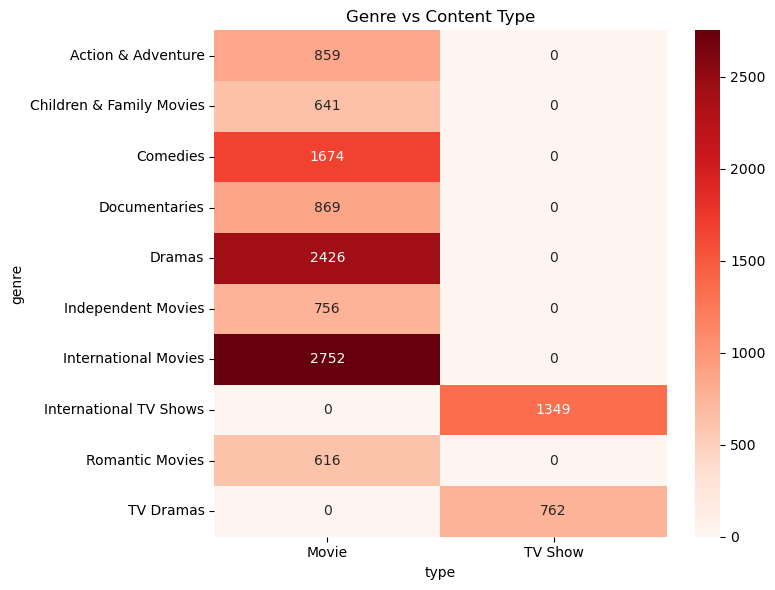

In [330]:
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds')
plt.title('Genre vs Content Type')
plt.tight_layout()
plt.show()

---
## 11. Summary Statistics

In [333]:
print('Total Titles      :', len(df))
print('Movies            :', len(df[df['type'] == 'Movie']))
print('TV Shows          :', len(df[df['type'] == 'TV Show']))
print('Avg Movie Length  :', round(movies['duration_clean'].mean(), 1), 'min')
print('Top Country       :', df['country'].value_counts().index[0])
print('Most Common Rating:', df['rating'].mode()[0])

Total Titles      : 8790
Movies            : 6126
TV Shows          : 2664
Avg Movie Length  : 99.6 min
Top Country       : United States
Most Common Rating: TV-MA


---
## 12. Export Cleaned Data

## Summary Stats

In [247]:
print(f"Total Movies              :  {len(df)}")
print(f"Movies                    :  {len(df[df['type']=='Movie'])}")
print(f"TV Shows                  :  {len(df[df['type']=='TV Show'])}")
print(f"Avg Movie Length          :  {round(movies['duration_clean'].mean(),1)} min")
print(f"Top Country               :  {df['country'].value_counts().index[0]}")
print(f"Most Common Rating        :  {df['rating'].mode()[0]}")

Total Movies              :  8790
Movies                    :  6126
TV Shows                  :  2664
Avg Movie Length          :  99.6 min
Top Country               :  United States
Most Common Rating        :  TV-MA


---
## 12. Export Cleaned Data

In [337]:
# Save the cleaned dataframe for future use
df.to_csv('Netflix_clean_file.csv', index=False)
print('File saved successfully.')

File saved successfully.
